# Appendice 1: velocità del vento

Nei dati raccolti da Meteotrentino la maggior parte delle voci relative alle velocità dei venti sono vuote. Tuttavia, per addestrare il modello, non possiamo fornirgli NaN ma solo valori numerici. Pertanto, le opzioni che individuiamo per procedere sono 3:
- 1. rinunciare ai dati dei venti
- 2. porre tutti i NaN a 0
- 3. sostituire i NaN con il valor medio dei dati effettivamente registrati

Tutte e tre le opzioni non ci soddisfano appieno: la prima ci fa rinunciare a dati potenzialmente importanti, mentre la seconda e la terza inseriscono nel modello dati che non sono reali e quindi lo rendono meno veritiero. Una quarta opzione poteva essere campionare dati con la stessa media e varianza dei dati raccolti e sostituirli ai NaN. Scegliamo di non percorrere questa strada poiché trasformerebbe la feature in dati randomici, puro rumore. Questo sarebbe anche peggio di rinunciare ai dati poiché non solo perderemmo le relative informazioni ma rischieremmo di imparare il rumore di questi nuovi dati.

Per scegliere tra i 3 approcci scegliamo di addestrare un modello con ciascuna delle opzioni e poi adottare nel resto dello studio l'approccio che conduce al modello migliore.

In [1]:
# preliminare
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from  sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn import metrics
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import TimeSeriesSplit

import sys
sys.path.append('../..')

import src.class_funcs as fs

In [2]:
#scelta seed rng
seed = 58327419

In [3]:
# cominciamo importando il dataframe precedentemente preparato
binary_class_df = pd.read_csv('../../data/processed/dataset_binary_class_processed.csv')

binary_class_df.head()

,station_Borgo Valsugana,station_Monte Gaza,station_Parco S. Chiara,station_Piana Rotaliana,station_Riva del Garda,station_Rovereto,station_Via Bolzano,elevation,day,cos_week_day,...,NO2_3,AQI_3,power_area_50_3,temperature,winds_spd,precipitation,PM10_diff,NO2_diff,AQI_diff,target
0,1,0,0,0,0,0,0,410,1,-0.900969,...,19.0,24.0,17.861264,10.950,NaN,0.0,1.0,1.0,4.0,1
1,1,0,0,0,0,0,0,410,1,-0.900969,...,17.0,22.0,14.669913,11.000,NaN,0.0,-2.0,-2.0,0.0,1
2,1,0,0,0,0,0,0,410,1,-0.900969,...,18.0,26.0,16.969367,10.925,NaN,0.0,5.0,0.0,6.0,1
3,1,0,0,0,0,0,0,410,1,-0.900969,...,16.0,26.0,15.329278,10.950,NaN,0.0,-5.0,-1.0,-10.0,1
4,1,0,0,0,0,0,0,410,1,-0.900969,...,16.0,32.0,17.519438,11.550,NaN,0.0,3.0,0.0,2.0,1


## Approccio 1: rinunciare ai dati

In [4]:
df_1 = binary_class_df.copy()

df_1 = df_1.drop(columns='winds_spd')

df_1.head()

,station_Borgo Valsugana,station_Monte Gaza,station_Parco S. Chiara,station_Piana Rotaliana,station_Riva del Garda,station_Rovereto,station_Via Bolzano,elevation,day,cos_week_day,...,PM10_3,NO2_3,AQI_3,power_area_50_3,temperature,precipitation,PM10_diff,NO2_diff,AQI_diff,target
0,1,0,0,0,0,0,0,410,1,-0.900969,...,19.0,19.0,24.0,17.861264,10.950,0.0,1.0,1.0,4.0,1
1,1,0,0,0,0,0,0,410,1,-0.900969,...,20.0,17.0,22.0,14.669913,11.000,0.0,-2.0,-2.0,0.0,1
2,1,0,0,0,0,0,0,410,1,-0.900969,...,21.0,18.0,26.0,16.969367,10.925,0.0,5.0,0.0,6.0,1
3,1,0,0,0,0,0,0,410,1,-0.900969,...,19.0,16.0,26.0,15.329278,10.950,0.0,-5.0,-1.0,-10.0,1
4,1,0,0,0,0,0,0,410,1,-0.900969,...,24.0,16.0,32.0,17.519438,11.550,0.0,3.0,0.0,2.0,1


### Pipeline

In [5]:
# individuiamo le colonne numeriche e quelle non numeriche
non_num_features = [col for col in df_1.columns if col.startswith('station_')]
num_features = df_1.columns.difference(non_num_features + ['target'])

# per il preprocessing usiamo ColumnTransformer, che permette di trasformare diverse colonne in modo diverso
preprocessor_binary = ColumnTransformer(
    [('num', StandardScaler(), num_features),
     ('one-hot', 'passthrough', non_num_features)])

tscv = TimeSeriesSplit(n_splits=5)

classifier_binary = LogisticRegressionCV(
    Cs=10,                                                          # numero di C = 1/lambda testati
    cv=tscv,                                                        # cv = n => n-fold cross validation
    solver='saga',                                                  # scegliamo saga, che è l'unico che supporta elasticnet
    l1_ratios=[0,0.25,0.5,0.75,1.0],                                # ratei tra l1 e l2 da testare
    scoring=metrics.make_scorer(metrics.matthews_corrcoef),         # usiamo mcc come score perché le classi sono sbilanciate e non abbiamo preferenze tra fpr e fnr
    max_iter=5000,                                                  # numero massimo di iterazioni per l'ottimizzazione
    n_jobs = -1,                                                    # usiamo la massima potenza disponibile nella CPU
    class_weight='balanced',                                        # bilancia in automatico le classi in base alla frequenza di input
    random_state=seed,                                             # per la riproducibilità dei risultati
    use_legacy_attributes=False)

# costruiamo la nostra pipeline vera e propria
model_binary_1 = Pipeline(steps=[('preprocessor', preprocessor_binary),('classifier', classifier_binary)])

In [6]:
# splittiamo il dataset e facciamo il fit al modello
feature_cols = list(num_features) + list(non_num_features)

# creiamo train, valid e test
X_train_1, _, X_test_1, y_train_1, _, y_test_1 = fs.get_train_valid_test(df_1, 0.8, 0.0, feature_cols)

In [7]:
# alleniamo il modello sul nostro insieme di training
model_binary_1.fit(X_train_1,y_train_1)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('one-hot', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transf

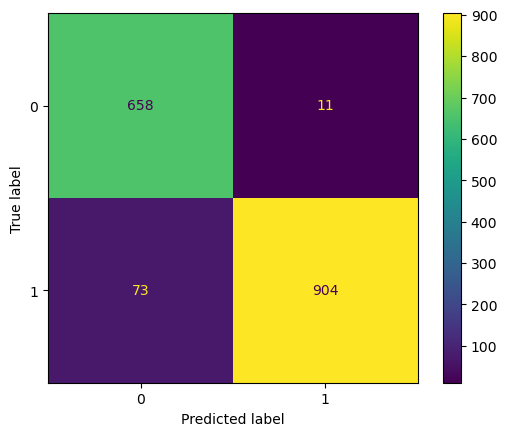

In [8]:
# disegnamo la confusion matrix in modo da capire se il nostro modello funziona o no
y_pred = model_binary_1.predict(X_test_1)
metrics.ConfusionMatrixDisplay.from_predictions(y_test_1,y_pred,display_labels=model_binary_1.classes_)

plt.show()

In [9]:
print('Performance del modello su train')
fs.get_performance_param(model_binary_1, X_train_1, y_train_1)
print('---------------------------------------------')
print('Performance del modello su test')
fs.get_performance_param(model_binary_1, X_test_1, y_test_1)

Performance del modello su train
Accuratezza:    0.93020
Precisione:     0.97360
Recall:         0.93191
F1 score:       0.95230
MCC:            0.82522
---------------------------------------------
Performance del modello su test
Accuratezza:    0.94897
Precisione:     0.98798
Recall:         0.92528
F1 score:       0.95560
MCC:            0.89842


## Approccio 2: mettere i NaN a 0

In [10]:
df_2 = binary_class_df.copy()

df_2['winds_spd'] = df_2['winds_spd'].fillna(0)

# togliamo le eventuali righe in cui sono rimasti NaN
df_2 = df_2.dropna()

df_2.head()

,station_Borgo Valsugana,station_Monte Gaza,station_Parco S. Chiara,station_Piana Rotaliana,station_Riva del Garda,station_Rovereto,station_Via Bolzano,elevation,day,cos_week_day,...,NO2_3,AQI_3,power_area_50_3,temperature,winds_spd,precipitation,PM10_diff,NO2_diff,AQI_diff,target
0,1,0,0,0,0,0,0,410,1,-0.900969,...,19.0,24.0,17.861264,10.950,0.0,0.0,1.0,1.0,4.0,1
1,1,0,0,0,0,0,0,410,1,-0.900969,...,17.0,22.0,14.669913,11.000,0.0,0.0,-2.0,-2.0,0.0,1
2,1,0,0,0,0,0,0,410,1,-0.900969,...,18.0,26.0,16.969367,10.925,0.0,0.0,5.0,0.0,6.0,1
3,1,0,0,0,0,0,0,410,1,-0.900969,...,16.0,26.0,15.329278,10.950,0.0,0.0,-5.0,-1.0,-10.0,1
4,1,0,0,0,0,0,0,410,1,-0.900969,...,16.0,32.0,17.519438,11.550,0.0,0.0,3.0,0.0,2.0,1


### Pipeline

In [11]:
# individuiamo le colonne numeriche e quelle non numeriche
non_num_features = [col for col in df_2.columns if col.startswith('station_')]
num_features = df_2.columns.difference(non_num_features + ['target'])

# per il preprocessing usiamo ColumnTransformer, che permette di trasformare diverse colonne in modo diverso
preprocessor_binary = ColumnTransformer(
    [('num', StandardScaler(), num_features),
     ('one-hot', 'passthrough', non_num_features)])

tscv = TimeSeriesSplit(n_splits=5)

classifier_binary = LogisticRegressionCV(
    Cs=10,                                                          # numero di C = 1/lambda testati
    cv=tscv,                                                        # cv = n => n-fold cross validation
    solver='saga',                                                  # scegliamo saga, che è l'unico che supporta elasticnet
    l1_ratios=[0,0.25,0.5,0.75,1.0],                                # ratei tra l1 e l2 da testare
    scoring=metrics.make_scorer(metrics.matthews_corrcoef),         # usiamo mcc come score perché le classi sono sbilanciate e non abbiamo preferenze tra fpr e fnr
    max_iter=5000,                                                  # numero massimo di iterazioni per l'ottimizzazione
    n_jobs = -1,                                                    # usiamo la massima potenza disponibile nella CPU
    class_weight='balanced',                                        # bilancia in automatico le classi in base alla frequenza di input
    random_state=seed,                                             # per la riproducibilità dei risultati
    use_legacy_attributes=False)

# costruiamo la nostra pipeline vera e propria
model_binary_2 = Pipeline(steps=[('preprocessor', preprocessor_binary),('classifier', classifier_binary)])

In [12]:
# splittiamo il dataset e facciamo il fit al modello
feature_cols = list(num_features) + list(non_num_features)

# creiamo train, valid e test
X_train_2, _, X_test_2, y_train_2, _, y_test_2 = fs.get_train_valid_test(df_2, 0.8, 0.0, feature_cols)

In [13]:
# alleniamo il modello sul nostro insieme di training
model_binary_2.fit(X_train_2,y_train_2)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('one-hot', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transf

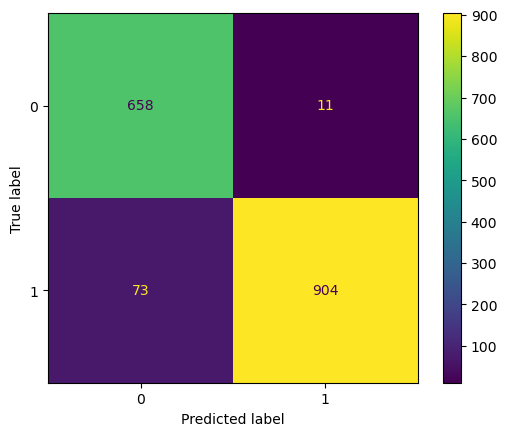

In [14]:
# disegnamo la confusion matrix in modo da capire se il nostro modello funziona o no
y_pred = model_binary_2.predict(X_test_2)
metrics.ConfusionMatrixDisplay.from_predictions(y_test_2,y_pred,display_labels=model_binary_2.classes_)

plt.show()

In [15]:
print('Performance del modello su train')
fs.get_performance_param(model_binary_2, X_train_2, y_train_2)
print('---------------------------------------------')
print('Performance del modello su test')
fs.get_performance_param(model_binary_2, X_test_2, y_test_2)

Performance del modello su train
Accuratezza:    0.92989
Precisione:     0.97359
Recall:         0.93150
F1 score:       0.95208
MCC:            0.82454
---------------------------------------------
Performance del modello su test
Accuratezza:    0.94897
Precisione:     0.98798
Recall:         0.92528
F1 score:       0.95560
MCC:            0.89842


## Approccio 3: mettere i NaN uguali alla media di train

In [16]:
df_3 = binary_class_df.copy()

# togliamo le eventuali righe in cui sono rimasti NaN
# per il momento lasciamo i NaN nelle colonne delle precipitazioni perché li sostituiremo dopo e altrimenti butteremmo via più righe del necessario
cols_to_check = df_3.columns.difference(['winds_spd'])
df_3 = df_3.dropna(subset=cols_to_check)

df_3.head()

,station_Borgo Valsugana,station_Monte Gaza,station_Parco S. Chiara,station_Piana Rotaliana,station_Riva del Garda,station_Rovereto,station_Via Bolzano,elevation,day,cos_week_day,...,NO2_3,AQI_3,power_area_50_3,temperature,winds_spd,precipitation,PM10_diff,NO2_diff,AQI_diff,target
0,1,0,0,0,0,0,0,410,1,-0.900969,...,19.0,24.0,17.861264,10.950,NaN,0.0,1.0,1.0,4.0,1
1,1,0,0,0,0,0,0,410,1,-0.900969,...,17.0,22.0,14.669913,11.000,NaN,0.0,-2.0,-2.0,0.0,1
2,1,0,0,0,0,0,0,410,1,-0.900969,...,18.0,26.0,16.969367,10.925,NaN,0.0,5.0,0.0,6.0,1
3,1,0,0,0,0,0,0,410,1,-0.900969,...,16.0,26.0,15.329278,10.950,NaN,0.0,-5.0,-1.0,-10.0,1
4,1,0,0,0,0,0,0,410,1,-0.900969,...,16.0,32.0,17.519438,11.550,NaN,0.0,3.0,0.0,2.0,1


### Pipeline

In [17]:
# individuiamo le colonne numeriche e quelle non numeriche
non_num_features = [col for col in df_3.columns if col.startswith('station_')]
num_features = df_3.columns.difference(non_num_features + ['target'])

# per il preprocessing usiamo ColumnTransformer, che permette di trasformare diverse colonne in modo diverso
preprocessor_binary = ColumnTransformer(
    [('num', StandardScaler(), num_features),
     ('one-hot', 'passthrough', non_num_features)])

tscv = TimeSeriesSplit(n_splits=5)

classifier_binary = LogisticRegressionCV(
    Cs=10,                                                          # numero di C = 1/lambda testati
    cv=tscv,                                                        # cv = n => n-fold cross validation
    solver='saga',                                                  # scegliamo saga, che è l'unico che supporta elasticnet
    l1_ratios=[0,0.25,0.5,0.75,1.0],                                # ratei tra l1 e l2 da testare
    scoring=metrics.make_scorer(metrics.matthews_corrcoef),         # usiamo mcc come score perché le classi sono sbilanciate e non abbiamo preferenze tra fpr e fnr
    max_iter=5000,                                                  # numero massimo di iterazioni per l'ottimizzazione
    n_jobs = -1,                                                    # usiamo la massima potenza disponibile nella CPU
    class_weight='balanced',                                        # bilancia in automatico le classi in base alla frequenza di input
    random_state=seed,                                             # per la riproducibilità dei risultati
    use_legacy_attributes=False)

# costruiamo la nostra pipeline vera e propria
model_binary_3 = Pipeline(steps=[('preprocessor', preprocessor_binary),('classifier', classifier_binary)])

In [18]:
# splittiamo il dataset e facciamo il fit al modello
feature_cols = list(num_features) + list(non_num_features)

# creiamo train, valid e test
X_train_3, _, X_test_3, y_train_3, _, y_test_3 = fs.get_train_valid_test(df_3, 0.8, 0.0, feature_cols)

# scegliamo di scalcolare la media sul train ed imporla anche sul test. In questo modo evitiamo parte del data leakage, anche se ne rimane
# comunque nella cross validation

train_mean = X_train_3['winds_spd'].mean()
for i in [X_train_3, X_test_3]:
    i['winds_spd'] = i['winds_spd'].fillna(train_mean)

X_train_3.head()

,AQI_1,AQI_2,AQI_3,AQI_diff,NO2_1,NO2_2,NO2_3,NO2_diff,PM10_1,PM10_2,...,sin_week_day,temperature,winds_spd,station_Borgo Valsugana,station_Monte Gaza,station_Parco S. Chiara,station_Piana Rotaliana,station_Riva del Garda,station_Rovereto,station_Via Bolzano
0,26.0,22.0,24.0,4.0,18.0,17.0,19.0,1.0,21.0,20.0,...,-0.433884,10.950,1.457936,1,0,0,0,0,0,0
1,26.0,26.0,22.0,0.0,16.0,18.0,17.0,-2.0,19.0,21.0,...,-0.433884,11.000,1.457936,1,0,0,0,0,0,0
2,32.0,26.0,26.0,6.0,16.0,16.0,18.0,0.0,24.0,19.0,...,-0.433884,10.925,1.457936,1,0,0,0,0,0,0
3,22.0,32.0,26.0,-10.0,15.0,16.0,16.0,-1.0,19.0,24.0,...,-0.433884,10.950,1.457936,1,0,0,0,0,0,0
4,24.0,22.0,32.0,2.0,15.0,15.0,16.0,0.0,22.0,19.0,...,-0.433884,11.550,1.457936,1,0,0,0,0,0,0


In [19]:
# alleniamo il modello sul nostro insieme di training
model_binary_3.fit(X_train_3,y_train_3)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('one-hot', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transf

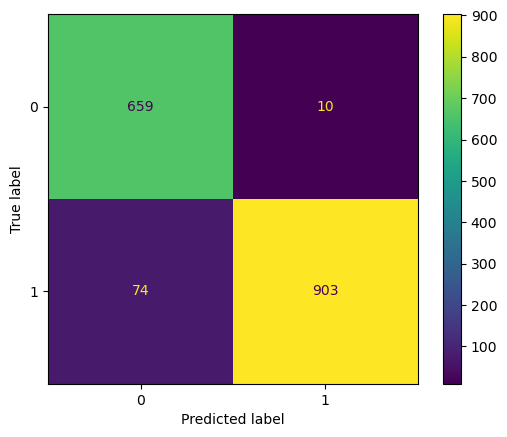

In [20]:
# disegnamo la confusion matrix in modo da capire se il nostro modello funziona o no
y_pred = model_binary_3.predict(X_test_3)
metrics.ConfusionMatrixDisplay.from_predictions(y_test_3,y_pred,display_labels=model_binary_3.classes_)

In [21]:
print('Performance del modello su train')
fs.get_performance_param(model_binary_3, X_train_3, y_train_3)
print('---------------------------------------------')
print('Performance del modello su test')
fs.get_performance_param(model_binary_3, X_test_3, y_test_3)

Performance del modello su train
Accuratezza:    0.93114
Precisione:     0.97467
Recall:         0.93212
F1 score:       0.95292
MCC:            0.82785
---------------------------------------------
Performance del modello su test
Accuratezza:    0.94897
Precisione:     0.98905
Recall:         0.92426
F1 score:       0.95556
MCC:            0.89864


## Conclusioni

In [22]:
print('---------------------------------------------')
print('Performance togliendo i venti')
fs.get_performance_param(model_binary_1, X_test_1, y_test_1)
print('---------------------------------------------')
print('Performance mettendo i nan a zero')
fs.get_performance_param(model_binary_2, X_test_2, y_test_2)
print('---------------------------------------------')
print('Performance mettendo i nan alla media')
fs.get_performance_param(model_binary_3, X_test_3, y_test_3)

---------------------------------------------
Performance togliendo i venti
Accuratezza:    0.94897
Precisione:     0.98798
Recall:         0.92528
F1 score:       0.95560
MCC:            0.89842
---------------------------------------------
Performance mettendo i nan a zero
Accuratezza:    0.94897
Precisione:     0.98798
Recall:         0.92528
F1 score:       0.95560
MCC:            0.89842
---------------------------------------------
Performance mettendo i nan alla media
Accuratezza:    0.94897
Precisione:     0.98905
Recall:         0.92426
F1 score:       0.95556
MCC:            0.89864


La performance non sembra cambiare in maniera rilevante dalla nostra scelta di come gestire i nan su winds_spd. Per tale motivo segliamo la soluzione più semplice e coerente: togliamo la colonna intera.